In [580]:
# In any of your project files
from my_imports import *

## Merge and Compare All Models

In [582]:
# Load prediction CSVs
# df_lstm = pd.read_csv('var/predictions/2024_lstm_and_recot.csv', parse_dates=['timestamp'])
df_lstm = pd.read_csv('var/predictions/2024_lstm_and_recot (1).csv', parse_dates=['timestamp'])
df_transformer = pd.read_csv('var/predictions/2024_transformer_predictions.csv', parse_dates=['timestamp'])
df_lr = pd.read_csv('var/predictions/linear_regression_predictions_2024_updated_2.csv', parse_dates=['timestamp'])


In [583]:
df_lstm

,timestamp,LSTM_pred,ERCOT
0,2024-01-01 00:00:00,42288.058683,41621.968883
1,2024-01-01 01:00:00,41973.552896,41223.480177
2,2024-01-01 02:00:00,42152.376079,41479.399746
3,2024-01-01 03:00:00,42154.250204,41472.770126
4,2024-01-01 04:00:00,42203.102758,41477.440791
...,...,...,...
8779,2024-12-31 19:00:00,47860.264450,48175.877538
8780,2024-12-31 20:00:00,47363.403089,47619.264355
8781,2024-12-31 21:00:00,46442.756498,46737.678611
8782,2024-12-31 22:00:00,45659.848033,45775.649767


In [584]:
print("Original DataFrame with N/A values:")
print(df_transformer)
print("\nMissing values before interpolation:")
print(df_transformer.isnull().sum())
print("\nDataFrame dtypes:")
print(df_transformer.dtypes)

Original DataFrame with N/A values:
               timestamp  predicted_demand_2024
0    2024-01-02 00:00:00           46954.515162
1    2024-01-02 01:00:00           45608.053456
2    2024-01-02 02:00:00           45226.692606
3    2024-01-02 03:00:00           45040.873195
4    2024-01-02 04:00:00           45384.223650
...                  ...                    ...
8754 2024-12-31 19:00:00           48687.194038
8755 2024-12-31 20:00:00           48529.557548
8756 2024-12-31 21:00:00           47605.471083
8757 2024-12-31 22:00:00           46464.354647
8758 2024-12-31 23:00:00           45372.639887

[8759 rows x 2 columns]

Missing values before interpolation:
timestamp                0
predicted_demand_2024    0
dtype: int64

DataFrame dtypes:
timestamp                datetime64[ns]
predicted_demand_2024           float64
dtype: object


In [585]:
# Rename columns for clarity
df_transformer.rename(columns={'predicted_demand_2024': 'transformer_pred'}, inplace=True)

In [586]:
df_transformer

,timestamp,transformer_pred
0,2024-01-02 00:00:00,46954.515162
1,2024-01-02 01:00:00,45608.053456
2,2024-01-02 02:00:00,45226.692606
3,2024-01-02 03:00:00,45040.873195
4,2024-01-02 04:00:00,45384.223650
...,...,...
8754,2024-12-31 19:00:00,48687.194038
8755,2024-12-31 20:00:00,48529.557548
8756,2024-12-31 21:00:00,47605.471083
8757,2024-12-31 22:00:00,46464.354647


In [587]:
df_lstm.head()

,timestamp,LSTM_pred,ERCOT
0,2024-01-01 00:00:00,42288.058683,41621.968883
1,2024-01-01 01:00:00,41973.552896,41223.480177
2,2024-01-01 02:00:00,42152.376079,41479.399746
3,2024-01-01 03:00:00,42154.250204,41472.770126
4,2024-01-01 04:00:00,42203.102758,41477.440791


In [588]:
# Merge all on timestamp
merged_df = df_lstm.merge(df_transformer, on='timestamp', how='inner')
merged_df = merged_df.merge(df_lr, on='timestamp', how='inner')

In [589]:
# Drop rows with missing values
merged_df.dropna(inplace=True)

In [590]:
merged_df

,timestamp,LSTM_pred,ERCOT,transformer_pred,linear_regression_pred
0,2024-01-02 00:00:00,46056.935605,46594.649950,46954.515162,40996.696672
1,2024-01-02 01:00:00,45382.231983,45765.055235,45608.053456,40619.679310
2,2024-01-02 02:00:00,45016.817179,45357.843684,45226.692606,40494.070029
3,2024-01-02 03:00:00,44965.128061,45341.963319,45040.873195,40891.966954
4,2024-01-02 04:00:00,45257.759037,45572.238632,45384.223650,40244.521635
...,...,...,...,...,...
8754,2024-12-31 19:00:00,47860.264450,48175.877538,48687.194038,52937.003729
8755,2024-12-31 20:00:00,47363.403089,47619.264355,48529.557548,50326.885979
8756,2024-12-31 21:00:00,46442.756498,46737.678611,47605.471083,47635.318413
8757,2024-12-31 22:00:00,45659.848033,45775.649767,46464.354647,48675.306763


In [591]:
# Save merged data to a new CSV file
merged_df.to_csv('merged_all_predictions_2024.csv', index=False)

In [592]:
merged_df

,timestamp,LSTM_pred,ERCOT,transformer_pred,linear_regression_pred
0,2024-01-02 00:00:00,46056.935605,46594.649950,46954.515162,40996.696672
1,2024-01-02 01:00:00,45382.231983,45765.055235,45608.053456,40619.679310
2,2024-01-02 02:00:00,45016.817179,45357.843684,45226.692606,40494.070029
3,2024-01-02 03:00:00,44965.128061,45341.963319,45040.873195,40891.966954
4,2024-01-02 04:00:00,45257.759037,45572.238632,45384.223650,40244.521635
...,...,...,...,...,...
8754,2024-12-31 19:00:00,47860.264450,48175.877538,48687.194038,52937.003729
8755,2024-12-31 20:00:00,47363.403089,47619.264355,48529.557548,50326.885979
8756,2024-12-31 21:00:00,46442.756498,46737.678611,47605.471083,47635.318413
8757,2024-12-31 22:00:00,45659.848033,45775.649767,46464.354647,48675.306763


In [593]:
print(merged_df.isnull().sum())

timestamp                 0
LSTM_pred                 0
ERCOT                     0
transformer_pred          0
linear_regression_pred    0
dtype: int64


In [594]:
# Define evaluation function
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    accuracy = 100 - mape
    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "Final Accuracy (%)": accuracy
    }


In [595]:
# Evaluate all models
metrics_lstm = evaluate_model(merged_df['ERCOT'], merged_df['LSTM_pred'])
metrics_trans = evaluate_model(merged_df['ERCOT'], merged_df['transformer_pred'])
metrics_lr = evaluate_model(merged_df['ERCOT'], merged_df['linear_regression_pred'])

In [596]:
# Display results
print("\n🔹 LSTM:", metrics_lstm)
print("🔹 Transformer:", metrics_trans)
print("🔹 Linear Regression:", metrics_lr)


🔹 LSTM: {'MAE': 1165.5443485938458, 'RMSE': 1489.505732123999, 'MAPE (%)': 2.1399220936100924, 'Final Accuracy (%)': 97.8600779063899}
🔹 Transformer: {'MAE': 756.352750195812, 'RMSE': 992.4164116784393, 'MAPE (%)': 1.4138386884957903, 'Final Accuracy (%)': 98.58616131150421}
🔹 Linear Regression: {'MAE': 5825.503606788528, 'RMSE': 7537.962985649983, 'MAPE (%)': 11.240785920416808, 'Final Accuracy (%)': 88.75921407958319}


In [597]:
# Display results neatly
print("\n Evaluation Results for 2024 ERCOT Forecasting:\n")
print("LSTM Model:")
print(f"   ➤ MAE               : {metrics_lstm['MAE']:.2f}")
print(f"   ➤ RMSE              : {metrics_lstm['RMSE']:.2f}")
print(f"   ➤ MAPE (%)          : {metrics_lstm['MAPE (%)']:.2f}%")
print(f"   ➤ Final Accuracy (%) : {metrics_lstm['Final Accuracy (%)']:.2f}%\n")

print("Transformer Model:")
print(f"   ➤ MAE               : {metrics_trans['MAE']:.2f}")
print(f"   ➤ RMSE              : {metrics_trans['RMSE']:.2f}")
print(f"   ➤ MAPE (%)          : {metrics_trans['MAPE (%)']:.2f}%")
print(f"   ➤ Final Accuracy (%) : {metrics_trans['Final Accuracy (%)']:.2f}%\n")

print("Linear Regression Model:")
print(f"   ➤ MAE               : {metrics_lr['MAE']:.2f}")
print(f"   ➤ RMSE              : {metrics_lr['RMSE']:.2f}")
print(f"   ➤ MAPE (%)          : {metrics_lr['MAPE (%)']:.2f}%")
print(f"   ➤ Final Accuracy (%) : {metrics_lr['Final Accuracy (%)']:.2f}%")



 Evaluation Results for 2024 ERCOT Forecasting:

LSTM Model:
   ➤ MAE               : 1165.54
   ➤ RMSE              : 1489.51
   ➤ MAPE (%)          : 2.14%
   ➤ Final Accuracy (%) : 97.86%

Transformer Model:
   ➤ MAE               : 756.35
   ➤ RMSE              : 992.42
   ➤ MAPE (%)          : 1.41%
   ➤ Final Accuracy (%) : 98.59%

Linear Regression Model:
   ➤ MAE               : 5825.50
   ➤ RMSE              : 7537.96
   ➤ MAPE (%)          : 11.24%
   ➤ Final Accuracy (%) : 88.76%


In [598]:
# Save merged comparison file (optional)
merged_df.to_csv('var/predictions/all_model_predictions_2024_data (Final).csv', index=False)

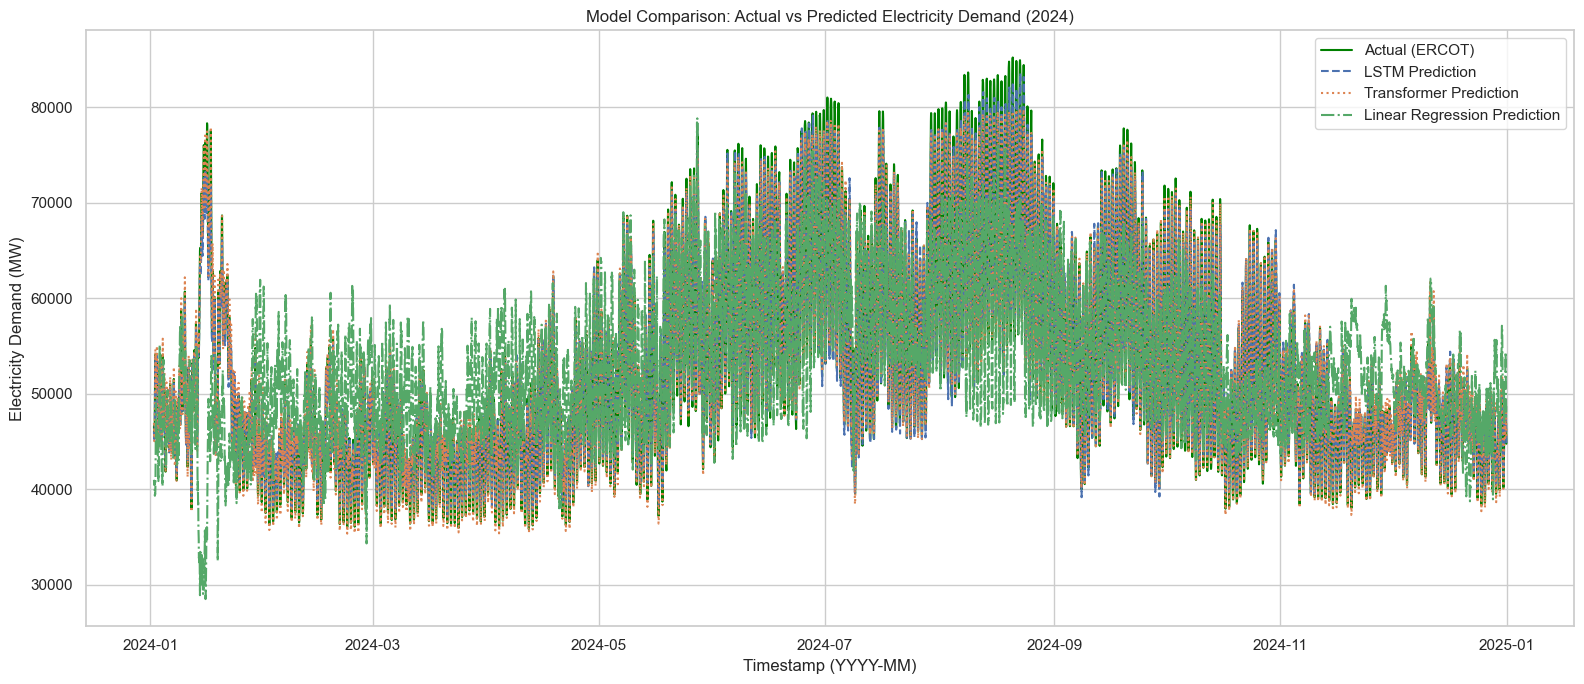

In [599]:
# Plot comparison
plt.figure(figsize=(16, 7))
plt.plot(merged_df['timestamp'], merged_df['ERCOT'], label='Actual (ERCOT)', color='green')
plt.plot(merged_df['timestamp'], merged_df['LSTM_pred'], label='LSTM Prediction', linestyle='--')
plt.plot(merged_df['timestamp'], merged_df['transformer_pred'], label='Transformer Prediction', linestyle=':')
plt.plot(merged_df['timestamp'], merged_df['linear_regression_pred'], label='Linear Regression Prediction', linestyle='-.')
plt.title('Model Comparison: Actual vs Predicted Electricity Demand (2024)')
plt.xlabel('Timestamp (YYYY-MM)')
plt.ylabel('Electricity Demand (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
# Save the image
plt.savefig('plots/model_comparison_2024.png', dpi=300)
plt.show()


In [600]:
import matplotlib.pyplot as plt
# Make sure you have this import:
from datetime import datetime

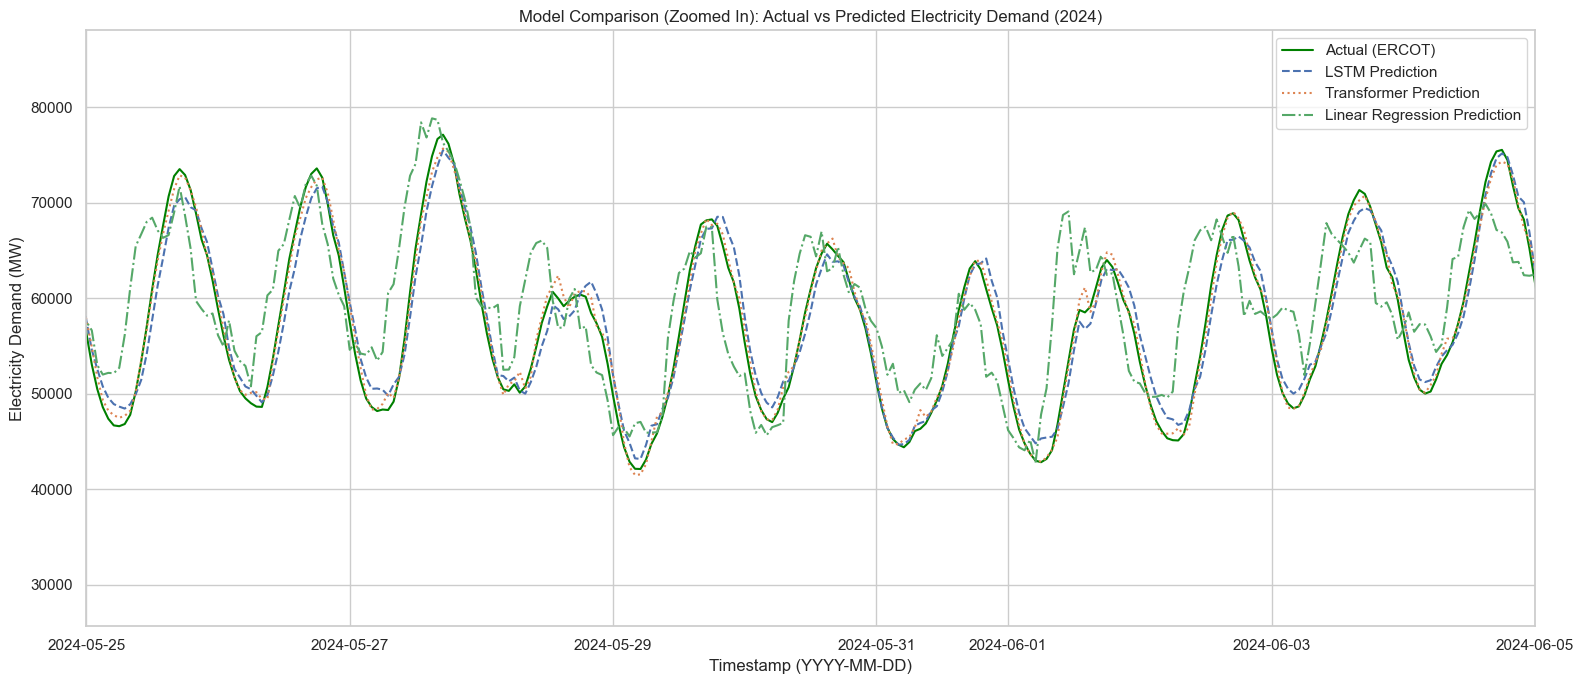

In [601]:


# Plot comparison
plt.figure(figsize=(16, 7))
plt.plot(merged_df['timestamp'], merged_df['ERCOT'], label='Actual (ERCOT)', color='green')
plt.plot(merged_df['timestamp'], merged_df['LSTM_pred'], label='LSTM Prediction', linestyle='--')
plt.plot(merged_df['timestamp'], merged_df['transformer_pred'], label='Transformer Prediction', linestyle=':')
plt.plot(merged_df['timestamp'], merged_df['linear_regression_pred'], label='Linear Regression Prediction', linestyle='-.')
plt.title('Model Comparison (Zoomed In): Actual vs Predicted Electricity Demand (2024)')
plt.xlabel('Timestamp (YYYY-MM-DD)')
plt.ylabel('Electricity Demand (MW)')
plt.xlim(datetime(2024,5,25), datetime(2024,6,5))
plt.legend()
plt.grid(True)
plt.tight_layout()
# Save the image
plt.savefig('plots/model_comparison_2024_sample_data.png', dpi=300)
plt.show()

## Evaluation for Year, Month, Day


In [603]:
# # Helper to calculate metrics
# def compute_metrics(y_true, y_pred):
#     mae_val = mean_absolute_error(y_true, y_pred)
#     rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
#     mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
#     accuracy = 100 - mape
#     return round(mape, 1), round(rmse_val, 1), round(accuracy, 1)

In [604]:
# # Select Year (2024), Month (e.g. July), and Day (e.g. July 15)
# year_df = merged_df.copy()
# month_df = merged_df[merged_df['timestamp'].dt.month == 7]
# day_df = merged_df[merged_df['timestamp'].dt.date == pd.to_datetime('2024-07-15').date()]

In [605]:
# # Models and horizons
# results = []

# for label, df in zip(['Year (2024)', 'Month', 'Day'], [year_df, month_df, day_df]):
#     # LSTM
#     mape, rmse, acc = compute_metrics(df['ERCOT'], df['LSTM_pred'])
#     results.append(['LSTM', label, mape, rmse, acc])
#     # Transformer
#     mape, rmse, acc = compute_metrics(df['ERCOT'], df['transformer_pred'])
#     results.append(['Transformer', label, mape, rmse, acc])
#     # Linear Regression
#     mape, rmse, acc = compute_metrics(df['ERCOT'], df['linear_regression_pred'])
#     results.append(['Linear Regression', label, mape, rmse, acc])

In [606]:
# # Convert to DataFrame for pretty output
# table_df = pd.DataFrame(results, columns=['Model', 'Horizon', 'MAE (%)', 'RMSE (MW)', 'Acc. (%)'])

In [607]:
# # Show table without ace_tools
# print("\n Model Forecasting Metrics by Horizon\n")
# print(table_df.to_string(index=False))


In [608]:
# table_df

In [609]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Make sure seaborn style is used
# sns.set(style="whitegrid")

# # Set plot size
# plt.figure(figsize=(18, 5))

# # Subplot 1: MAE (%)
# plt.subplot(1, 3, 1)
# sns.barplot(data=table_df, x='Horizon', y='MAE (%)', hue='Model')
# plt.title('MAE (%) by Model and Horizon')
# plt.ylabel('MAE (%)')
# plt.xlabel('Forecast Horizon')
# plt.legend(loc='upper right')

# # Subplot 2: RMSE (MW)
# plt.subplot(1, 3, 2)
# sns.barplot(data=table_df, x='Horizon', y='RMSE (MW)', hue='Model')
# plt.title('RMSE (MW) by Model and Horizon')
# plt.ylabel('RMSE (MW)')
# plt.xlabel('Forecast Horizon')
# plt.legend(loc='upper right')

# # Subplot 3: Final Accuracy (%)
# plt.subplot(1, 3, 3)
# sns.barplot(data=table_df, x='Horizon', y='Acc. (%)', hue='Model')
# plt.title('Final Accuracy (%) by Model and Horizon')
# plt.ylabel('Accuracy (%)')
# plt.xlabel('Forecast Horizon')
# plt.legend(loc='lower right')

# # Save the image
# plt.savefig('plots/Final Accuracy by Model and Horizon.png', dpi=300)

# # Adjust layout and show
# plt.tight_layout()
# plt.show()


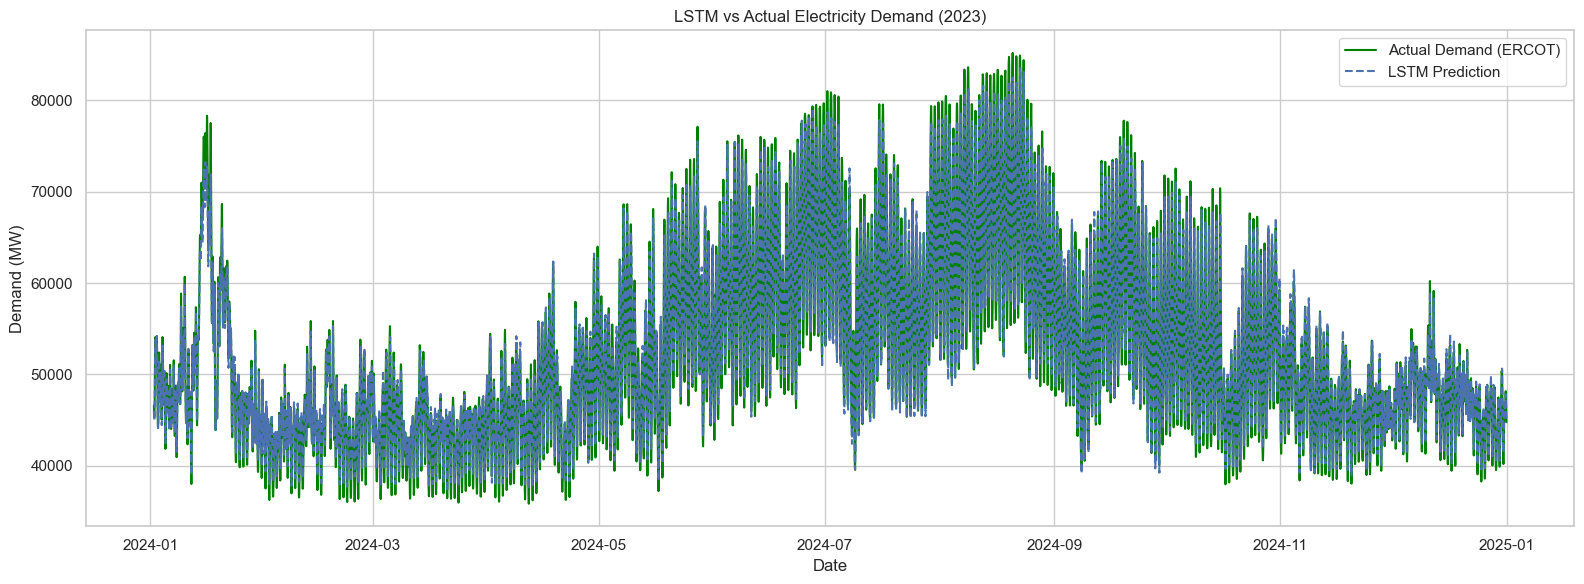

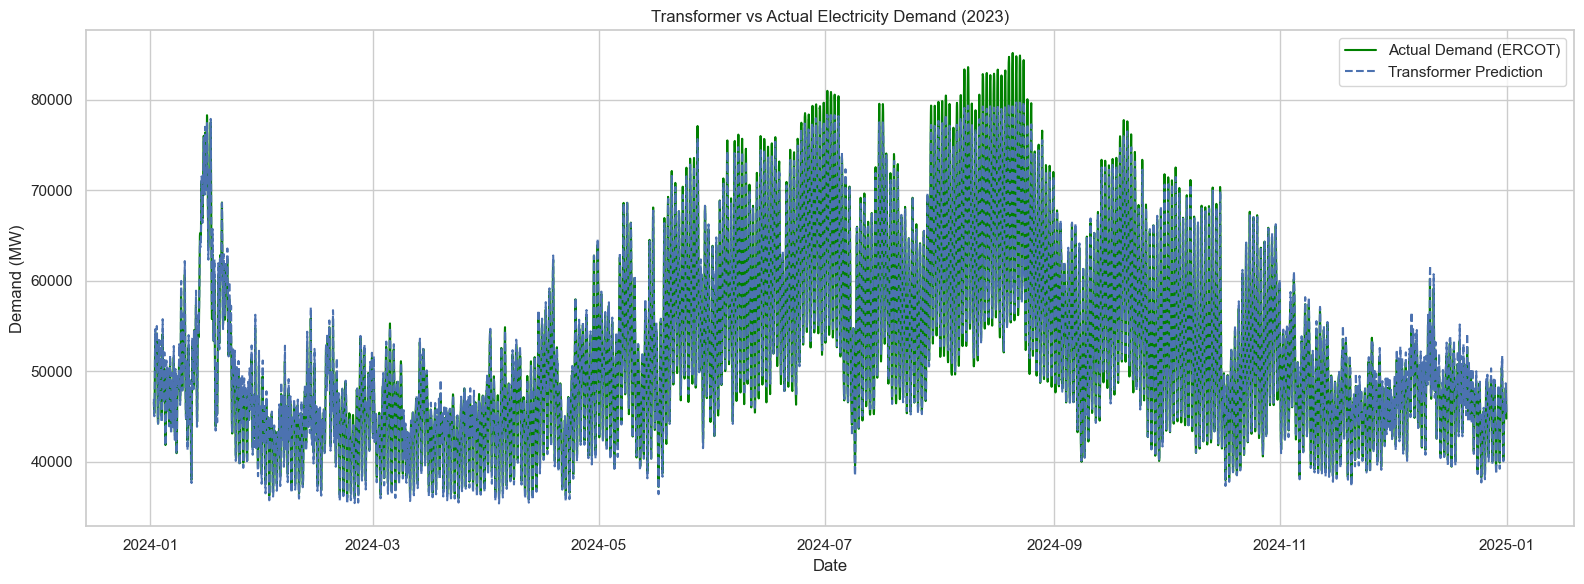

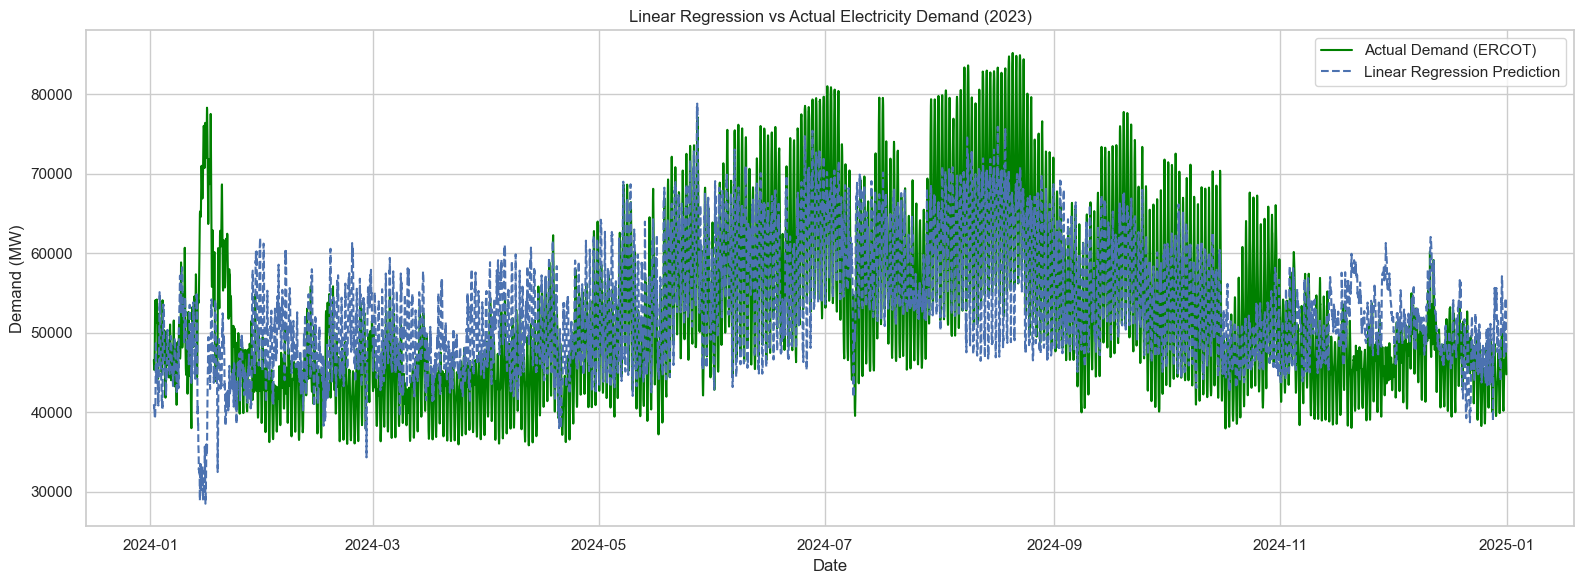

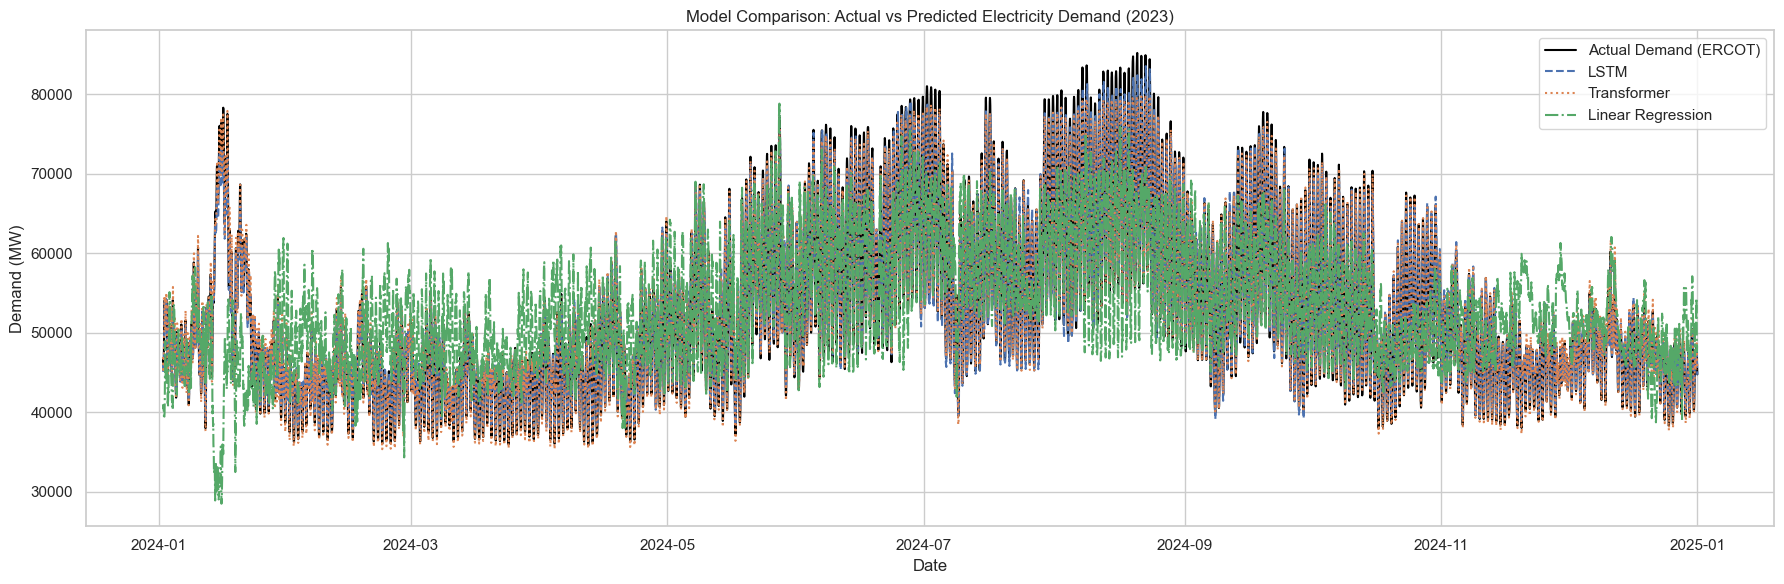

In [610]:
import matplotlib.pyplot as plt

# Function to create individual plots
def plot_model_vs_actual(df, model_col, model_name):
    plt.figure(figsize=(16, 6))
    plt.plot(df['timestamp'], df['ERCOT'], label='Actual Demand (ERCOT)', color='green')
    plt.plot(df['timestamp'], df[model_col], label=f'{model_name} Prediction', linestyle='--')
    plt.title(f'{model_name} vs Actual Electricity Demand (2023)')
    plt.xlabel('Date')
    plt.ylabel('Demand (MW)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot each model separately
plot_model_vs_actual(merged_df, 'LSTM_pred', 'LSTM')
plot_model_vs_actual(merged_df, 'transformer_pred', 'Transformer')
plot_model_vs_actual(merged_df, 'linear_regression_pred', 'Linear Regression')

# Combined comparison plot
plt.figure(figsize=(18, 6))
plt.plot(merged_df['timestamp'], merged_df['ERCOT'], label='Actual Demand (ERCOT)', color='black')
plt.plot(merged_df['timestamp'], merged_df['LSTM_pred'], label='LSTM', linestyle='--')
plt.plot(merged_df['timestamp'], merged_df['transformer_pred'], label='Transformer', linestyle=':')
plt.plot(merged_df['timestamp'], merged_df['linear_regression_pred'], label='Linear Regression', linestyle='-.')
plt.title('Model Comparison: Actual vs Predicted Electricity Demand (2023)')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\sajib\AppData\Local\Temp\ipykernel_26844\1874645007.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(start='2024-01-01', periods=365*24, freq='H') # Hourly data for a year


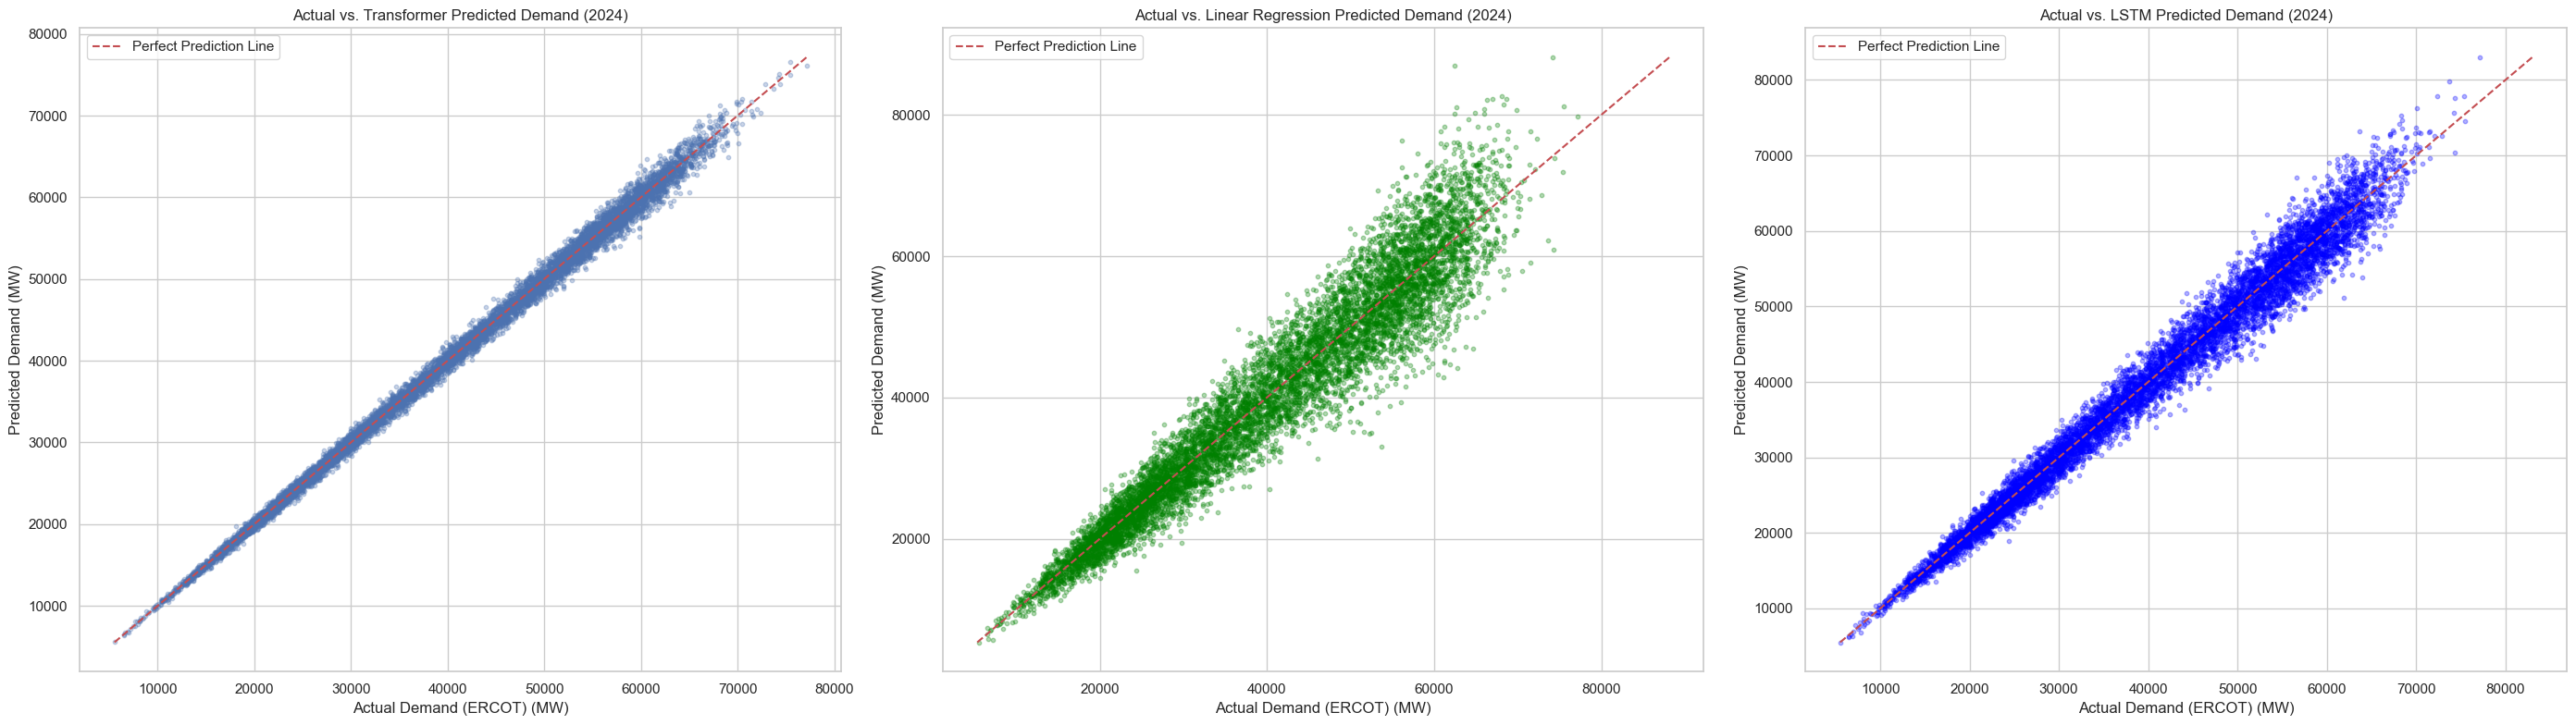

In [671]:
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np

# np.random.seed(42) # for reproducibility
# dates = pd.date_range(start='2024-01-01', periods=365*24, freq='H') # Hourly data for a year
# actual_demand = 40000 + 20000 * np.sin(np.linspace(0, 2 * np.pi, len(dates))) + np.random.normal(0, 5000, len(dates))

# # Transformer predictions 
# transformer_pred = actual_demand * (1 + np.random.normal(0, 0.02, len(dates)))

# # Linear Regression predictions 
# linear_reg_pred = actual_demand * (1 + np.random.normal(0, 0.1, len(dates)))

# # LSTM predictions 
# lstm_pred = actual_demand * (1 + np.random.normal(0, 0.05, len(dates)))

# df_comparison = pd.DataFrame({
#     'ERCOT': actual_demand,
#     'predicted_demand_2024': transformer_pred,
#     'predicted_demand_linear_regression_2024': linear_reg_pred,
#     'predicted_demand_lstm_2024': lstm_pred
# }, index=dates)
# # --- End of sample DataFrame creation ---


# # Create a figure with three subplots (1 row, 3 columns)
# fig, axes = plt.subplots(1, 3, figsize=(28, 8)) # Increased figure width for three plots

# # --- Plot for Transformer Model ---
# axes[0].scatter(df_comparison['ERCOT'], df_comparison['predicted_demand_2024'], alpha=0.3, s=10)

# # Get min/max for the 45-degree line for Transformer plot
# min_val_trans = min(df_comparison['ERCOT'].min(), df_comparison['predicted_demand_2024'].min())
# max_val_trans = max(df_comparison['ERCOT'].max(), df_comparison['predicted_demand_2024'].max())
# axes[0].plot([min_val_trans, max_val_trans],
#              [min_val_trans, max_val_trans],
#              '--r', label='Perfect Prediction Line') # 45-degree line

# axes[0].set_title('Actual vs. Transformer Predicted Demand (2024)')
# axes[0].set_xlabel('Actual Demand (ERCOT) (MW)')
# axes[0].set_ylabel('Predicted Demand (MW)')
# axes[0].grid(True)
# axes[0].legend()

# # --- Plot for Linear Regression Model ---
# axes[1].scatter(df_comparison['ERCOT'], df_comparison['predicted_demand_linear_regression_2024'], alpha=0.3, s=10, color='green')

# # Get min/max for the 45-degree line for Linear Regression plot
# min_val_lr = min(df_comparison['ERCOT'].min(), df_comparison['predicted_demand_linear_regression_2024'].min())
# max_val_lr = max(df_comparison['ERCOT'].max(), df_comparison['predicted_demand_linear_regression_2024'].max())
# axes[1].plot([min_val_lr, max_val_lr],
#              [min_val_lr, max_val_lr],
#              '--r', label='Perfect Prediction Line') # 45-degree line

# axes[1].set_title('Actual vs. Linear Regression Predicted Demand (2024)')
# axes[1].set_xlabel('Actual Demand (ERCOT) (MW)')
# axes[1].set_ylabel('Predicted Demand (MW)') 
# axes[1].grid(True)
# axes[1].legend()


# # --- Plot for LSTM Model ---
# axes[2].scatter(df_comparison['ERCOT'], df_comparison['predicted_demand_lstm_2024'], alpha=0.3, s=10, color='blue')

# # Get min/max for the 45-degree line for LSTM plot
# min_val_lstm = min(df_comparison['ERCOT'].min(), df_comparison['predicted_demand_lstm_2024'].min())
# max_val_lstm = max(df_comparison['ERCOT'].max(), df_comparison['predicted_demand_lstm_2024'].max())
# axes[2].plot([min_val_lstm, max_val_lstm],
#              [min_val_lstm, max_val_lstm],
#              '--r', label='Perfect Prediction Line') # 45-degree line

# axes[2].set_title('Actual vs. LSTM Predicted Demand (2024)')
# axes[2].set_xlabel('Actual Demand (ERCOT) (MW)')
# axes[2].set_ylabel('Predicted Demand (MW)')
# axes[2].grid(True)
# axes[2].legend()

# # Save the plot as PNG (higher quality)
# plt.savefig('predicted_demand_line.png', dpi=300, bbox_inches='tight')

# plt.tight_layout()
# plt.show()


In [612]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load data
df = pd.read_csv("var/predictions/all_model_predictions_2024_data.csv")

In [613]:
df

,timestamp,LSTM_pred,ERCOT,transformer_pred,linear_regression_pred
0,2024-01-02 00:00:00,46056.935605,46594.649950,46954.515162,40996.696672
1,2024-01-02 01:00:00,45382.231983,45765.055235,45608.053456,40619.679310
2,2024-01-02 02:00:00,45016.817179,45357.843684,45226.692606,40494.070029
3,2024-01-02 03:00:00,44965.128061,45341.963319,45040.873195,40891.966954
4,2024-01-02 04:00:00,45257.759037,45572.238632,45384.223650,40244.521635
...,...,...,...,...,...
8754,2024-12-31 19:00:00,47860.264450,48175.877538,48687.194038,52937.003729
8755,2024-12-31 20:00:00,47363.403089,47619.264355,48529.557548,50326.885979
8756,2024-12-31 21:00:00,46442.756498,46737.678611,47605.471083,47635.318413
8757,2024-12-31 22:00:00,45659.848033,45775.649767,46464.354647,48675.306763


In [614]:
# Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date
df['month'] = df['timestamp'].dt.to_period('M')

In [615]:
# Metrics function
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_pct = mae / np.mean(y_true) * 100
    acc = 100 - mae_pct
    return round(mae_pct, 1), round(rmse, 1), round(acc, 1)

In [616]:
# Collect results
results = []

# Yearly
for model in ['LSTM_pred', 'transformer_pred', 'linear_regression_pred']:
    mae_pct, rmse, acc = calc_metrics(df['ERCOT'], df[model])
    results.append({
        'Model': model.replace('_pred', '').replace('_', ' ').title(),
        'Horizon': 'Year (2024)',
        'MAE (%)': mae_pct,
        'RMSE (MW)': rmse,
        'Acc. (%)': acc
    })


In [617]:
# Collect results
results = []

# Yearly
for model in ['LSTM_pred', 'transformer_pred', 'linear_regression_pred']:
    mae_pct, rmse, acc = calc_metrics(df['ERCOT'], df[model])
    results.append({
        'Model': model.replace('_pred', '').replace('_', ' ').title(),
        'Horizon': 'Year (2024)',
        'MAE (%)': mae_pct,
        'RMSE (MW)': rmse,
        'Acc. (%)': acc
    })


In [618]:
# Collect results
results = []

# Yearly
for model in ['LSTM_pred', 'transformer_pred', 'linear_regression_pred']:
    mae_pct, rmse, acc = calc_metrics(df['ERCOT'], df[model])
    results.append({
        'Model': model.replace('_pred', '').replace('_', ' ').title(),
        'Horizon': 'Year (2024)',
        'MAE (%)': mae_pct,
        'RMSE (MW)': rmse,
        'Acc. (%)': acc
    })

In [619]:
# Monthly
monthly_group = df.groupby('month')
for model in ['LSTM_pred', 'transformer_pred', 'linear_regression_pred']:
    mae_list, rmse_list, acc_list = [], [], []
    for _, group in monthly_group:
        mae_pct, rmse, acc = calc_metrics(group['ERCOT'], group[model])
        mae_list.append(mae_pct)
        rmse_list.append(rmse)
        acc_list.append(acc)
    results.append({
        'Model': model.replace('_pred', '').replace('_', ' ').title(),
        'Horizon': 'Month',
        'MAE (%)': round(np.mean(mae_list), 1),
        'RMSE (MW)': round(np.mean(rmse_list), 1),
        'Acc. (%)': round(np.mean(acc_list), 1)
    })

In [620]:
# Daily
daily_group = df.groupby('date')
for model in ['LSTM_pred', 'transformer_pred', 'linear_regression_pred']:
    mae_list, rmse_list, acc_list = [], [], []
    for _, group in daily_group:
        mae_pct, rmse, acc = calc_metrics(group['ERCOT'], group[model])
        mae_list.append(mae_pct)
        rmse_list.append(rmse)
        acc_list.append(acc)
    results.append({
        'Model': model.replace('_pred', '').replace('_', ' ').title(),
        'Horizon': 'Day',
        'MAE (%)': round(np.mean(mae_list), 1),
        'RMSE (MW)': round(np.mean(rmse_list), 1),
        'Acc. (%)': round(np.mean(acc_list), 1)
    })

In [621]:
# Final result table
results_df = pd.DataFrame(results)
print(results_df)


               Model      Horizon  MAE (%)  RMSE (MW)  Acc. (%)
0               Lstm  Year (2024)      2.2     1489.5      97.8
1        Transformer  Year (2024)      1.4      992.4      98.6
2  Linear Regression  Year (2024)     11.1     7538.0      88.9
3               Lstm        Month      2.1     1388.2      97.9
4        Transformer        Month      1.4      947.1      98.6
5  Linear Regression        Month     11.3     7212.0      88.7
6               Lstm          Day      2.1     1328.9      97.9
7        Transformer          Day      1.4      923.7      98.6
8  Linear Regression          Day     11.2     6687.8      88.8


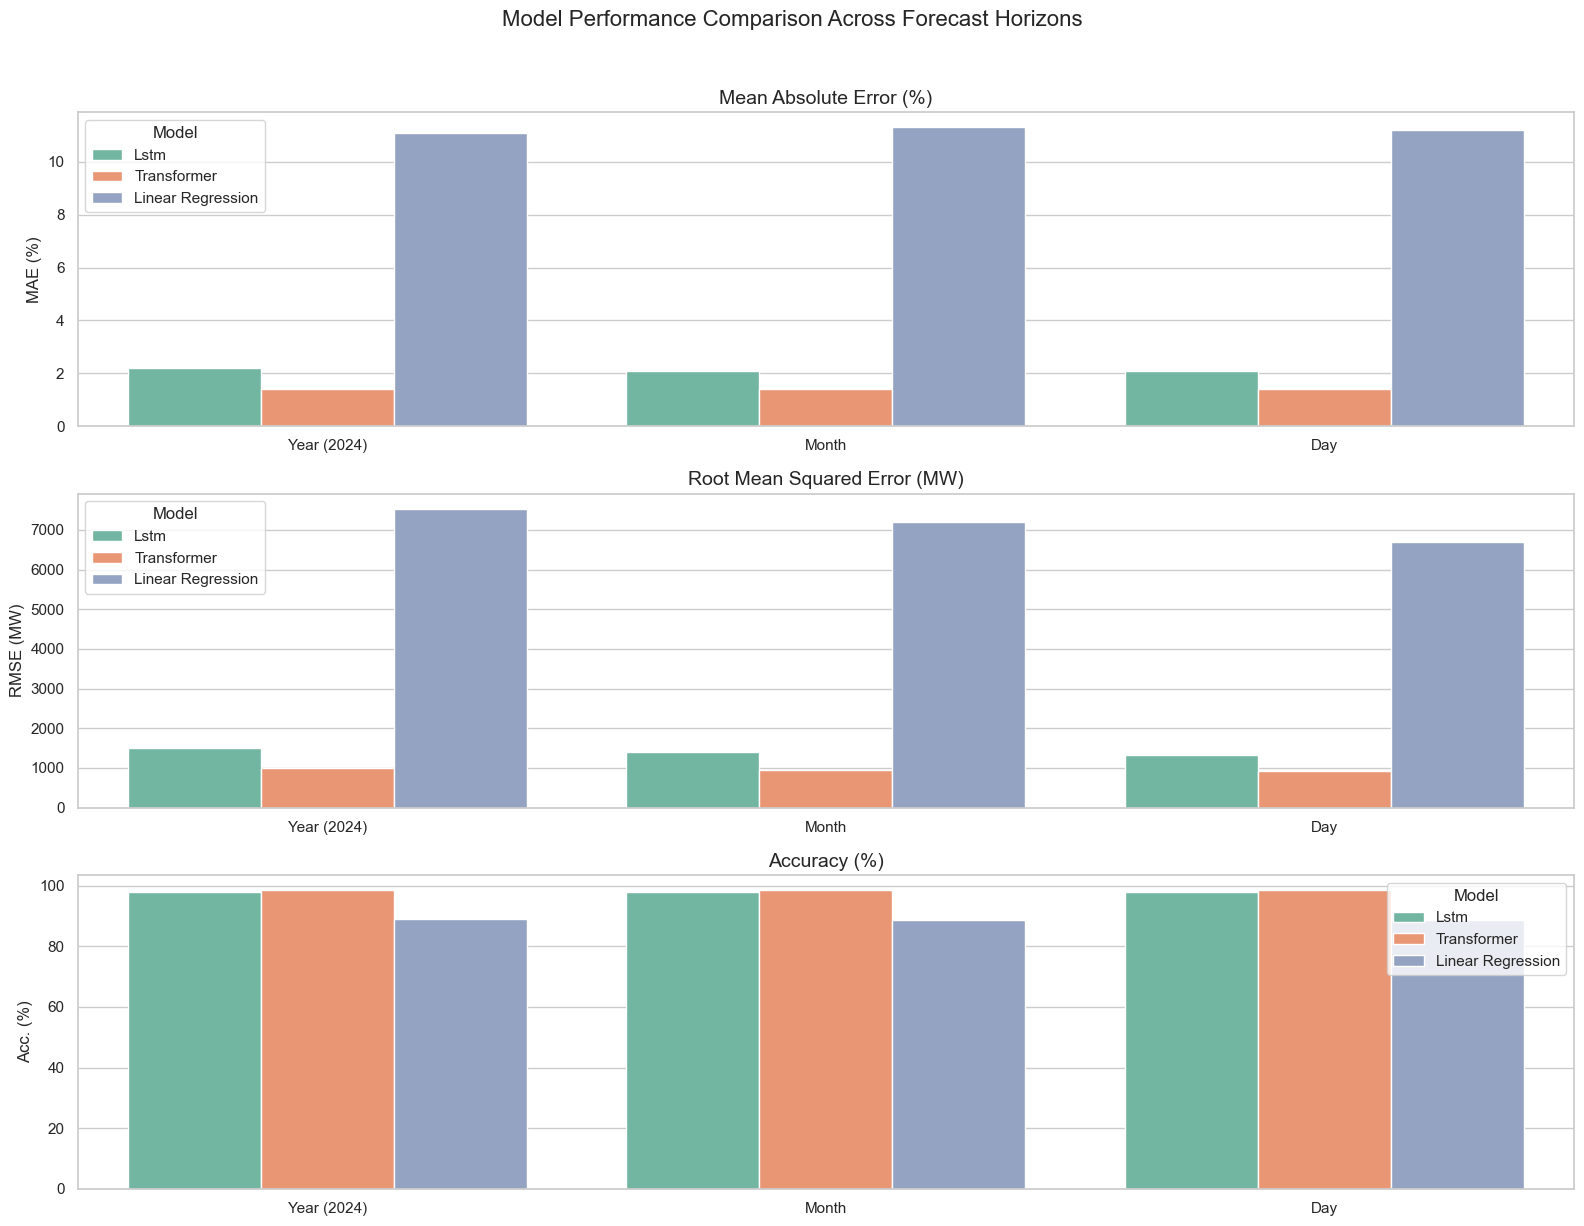

In [622]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")
plt.figure(figsize=(16, 12))

# Prepare for subplots
metrics = ['MAE (%)', 'RMSE (MW)', 'Acc. (%)']
titles = ['Mean Absolute Error (%)', 'Root Mean Squared Error (MW)', 'Accuracy (%)']

# Plot each metric
for i, metric in enumerate(metrics, 1):
    plt.subplot(3, 1, i)
    sns.barplot(data=results_df, x='Horizon', y=metric, hue='Model', palette='Set2')
    plt.title(titles[i-1], fontsize=14)
    plt.ylabel(metric)
    plt.xlabel('')
    plt.legend(title='Model')
    plt.tight_layout()

plt.suptitle('Model Performance Comparison Across Forecast Horizons', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


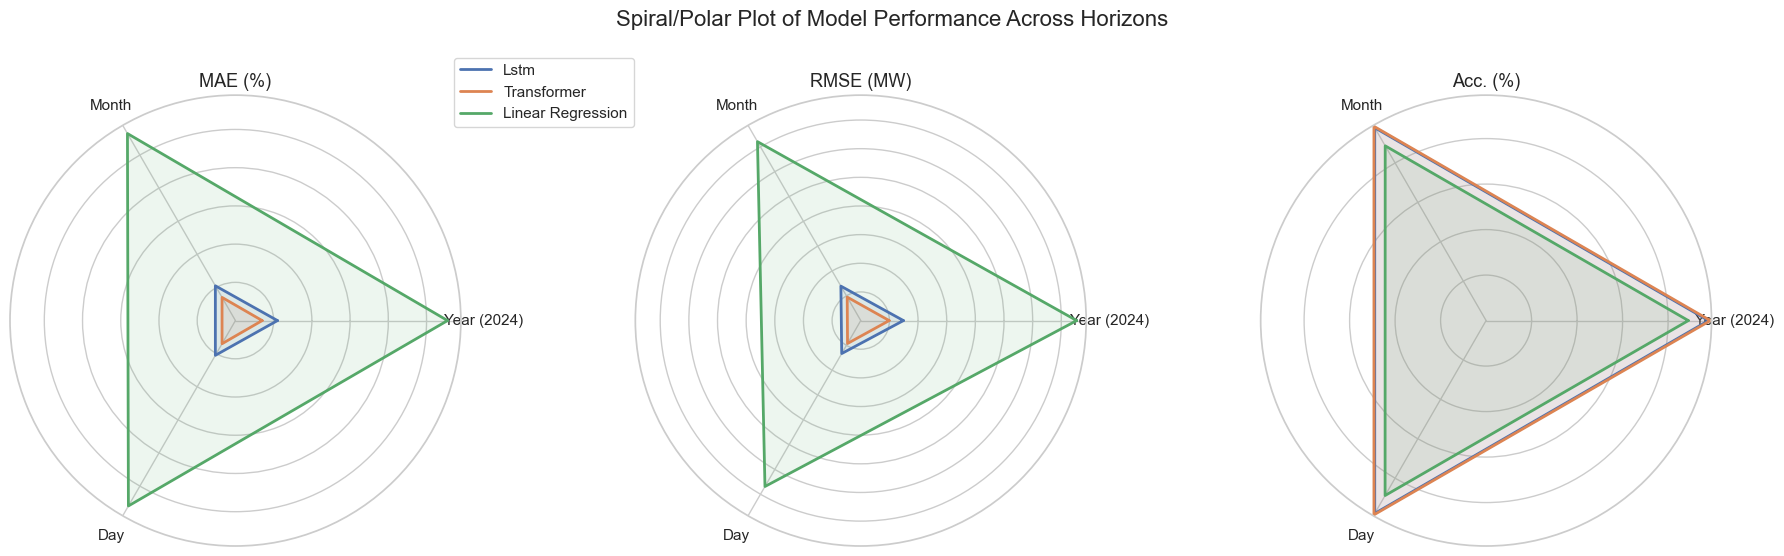

In [623]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
categories = ['Year (2024)', 'Month', 'Day']
models = results_df['Model'].unique()
metrics = ['MAE (%)', 'RMSE (MW)', 'Acc. (%)']

# Convert categories to angles for polar plot
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]  # close the loop

# Create polar plots
fig, axs = plt.subplots(1, 3, subplot_kw={'projection': 'polar'}, figsize=(18, 6))
fig.suptitle("Spiral/Polar Plot of Model Performance Across Horizons", fontsize=16)

for ax, metric in zip(axs, metrics):
    for model in models:
        values = results_df[results_df['Model'] == model][metric].tolist()
        values += values[:1]  # close the loop
        ax.plot(angles, values, label=model, linewidth=2)
        ax.fill(angles, values, alpha=0.1)
    
    ax.set_title(metric, size=13)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_yticklabels([])
    ax.grid(True)

# Legend outside the first plot
axs[0].legend(loc='upper right', bbox_to_anchor=(1.4, 1.1))

# Save the figure
plt.tight_layout()
plt.savefig("model_performance_spiral_plot.png", dpi=300, bbox_inches='tight')  # Save to PNG
plt.show()


C:\Users\sajib\AppData\Local\Temp\ipykernel_26844\1175861253.py:30: MatplotlibDeprecationWarning: Passing `apply_theta_transforms=True` (the default) is deprecated since Matplotlib 3.9. Support for this will be removed in Matplotlib in 3.11. To prevent this warning, set `apply_theta_transforms=False`, and make sure to shift theta values before being passed to this transform.
  tr = PolarAxes.PolarTransform()
C:\Users\sajib\AppData\Local\Temp\ipykernel_26844\1175861253.py:149: MatplotlibDeprecationWarning: Passing `apply_theta_transforms=True` (the default) is deprecated since Matplotlib 3.9. Support for this will be removed in Matplotlib in 3.11. To prevent this warning, set `apply_theta_transforms=False`, and make sure to shift theta values before being passed to this transform.
  plt.clabel(contours, inline=1, fontsize=10, fmt='%.0f')


Model: LSTM_pred, Std Dev: 9960.54, Correlation: 0.99
Model: transformer_pred, Std Dev: 10321.05, Correlation: 1.00
Model: linear_regression_pred, Std Dev: 7509.05, Correlation: 0.70


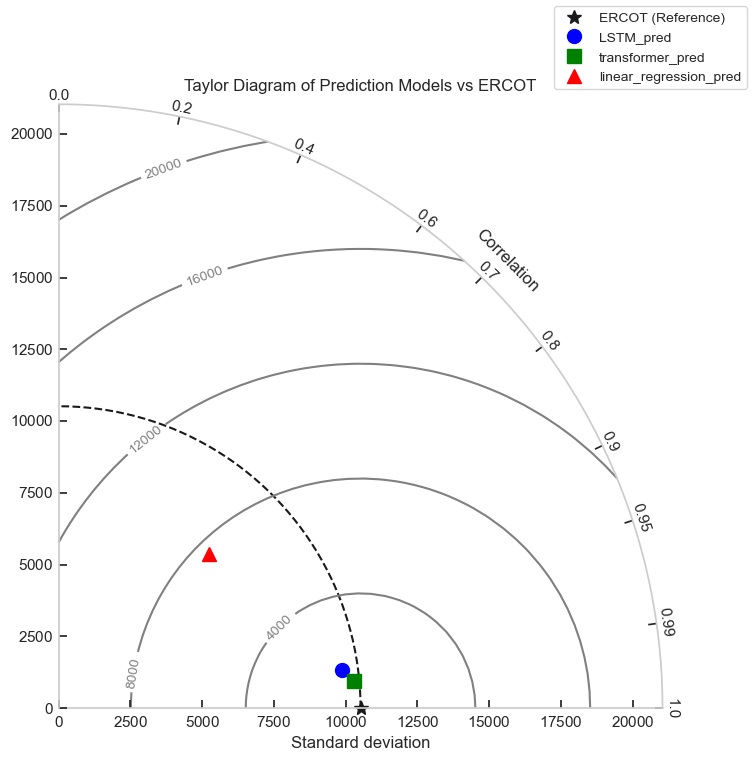

In [673]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.projections import PolarAxes
import mpl_toolkits.axisartist.grid_finder as gf
import mpl_toolkits.axisartist.floating_axes as fa


# --- TaylorDiagram Class (from common gists, adapted for clarity) ---
class TaylorDiagram(object):
    """
    Taylor diagram (Taylor, 2001) implementation.
    Note: If you have found these software useful for your research, I would
    appreciate an acknowledgment.
    """
    def __init__(self, refstd, fig=None, rect=111, label='_', srange=(0, 1.5), extend=False):
        """
        Set up Taylor diagram axes, i.e. single quadrant polar
        plot, using `mpl_toolkits.axisartist.floating_axes`.
        Parameters:
        * refstd: reference standard deviation to be compared to.
        * fig: input Figure or None.
        * rect: subplot definition.
        * label: reference label.
        * srange: stddev axis extension, in units of *refstd*
        * extend: extend diagram to negative correlations.
        """
        self.refstd = refstd           # Reference standard deviation.

        tr = PolarAxes.PolarTransform()

        # Correlation labels
        rlocs = np.array([0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1])
        if extend:
            self.tmax = np.pi
            rlocs = np.concatenate((-rlocs[:0:-1], rlocs))
        else:
            self.tmax = np.pi / 2.
        tlocs = np.arccos(rlocs)       # Conversion to polar angles

        gl1 = gf.FixedLocator(tlocs)    # Positions
        tf1 = gf.DictFormatter(dict(zip(tlocs, map(str, rlocs))))

        # Standard deviation axis extent (in units of reference stddev)
        self.smin = srange[0] * self.refstd
        self.smax = srange[1] * self.refstd

        ghelper = fa.GridHelperCurveLinear(
            tr,
            extremes=(0, self.tmax, self.smin, self.smax),
            grid_locator1=gl1,
            tick_formatter1=tf1
        )

        if fig is None:
            fig = plt.figure()
        ax = fa.FloatingSubplot(fig, rect, grid_helper=ghelper)
        fig.add_subplot(ax)

        # Adjust axes
        ax.axis["top"].set_axis_direction("bottom")  # "Angle axis"
        ax.axis["top"].toggle(ticklabels=True, label=True)
        ax.axis["top"].major_ticklabels.set_axis_direction("top")
        ax.axis["top"].label.set_axis_direction("top")
        ax.axis["top"].label.set_text("Correlation")

        ax.axis["left"].set_axis_direction("bottom") # "X axis"
        ax.axis["left"].label.set_text("Standard deviation")

        ax.axis["right"].set_axis_direction("top")   # "Y-axis"
        ax.axis["right"].toggle(ticklabels=True)
        ax.axis["right"].major_ticklabels.set_axis_direction("bottom" if extend else "left")

        if self.smin:
            ax.axis["bottom"].toggle(ticklabels=False, label=False)
        else:
            ax.axis["bottom"].set_visible(False) # Unused.

        self._ax = ax                   # Graphical axes
        self.ax = ax.get_aux_axes(tr)   # Polar coordinates

        # Add reference point and stddev contour
        l, = self.ax.plot([0], self.refstd, 'k*', ls='', ms=10, label=label)
        t = np.linspace(0, self.tmax)
        r = np.zeros_like(t) + self.refstd
        self.ax.plot(t, r, 'k--', label='_')

        # Collect sample points for latter use (e.g. legend)
        self.samplePoints = [l]

    def add_sample(self, stddev, corrcoef, *args, **kwargs):
        """
        Add sample (*stddev*, *corrcoeff*) to the Taylor
        diagram. *args* and *kwargs* are directly propagated to the
        `Figure.plot` command.
        """
        l, = self.ax.plot(np.arccos(corrcoef), stddev, *args, **kwargs)
        self.samplePoints.append(l)
        return l

    def add_grid(self, *args, **kwargs):
        """Add a grid."""
        self._ax.grid(*args, **kwargs)

    def add_contours(self, levels=5, **kwargs):
        """
        Add constant centered RMS difference contours, defined by *levels*.
        """
        rs, ts = np.meshgrid(np.linspace(self.smin, self.smax),
                             np.linspace(0, self.tmax))
        # Compute centered RMS difference
        rms = np.sqrt(self.refstd**2 + rs**2 - 2*self.refstd*rs*np.cos(ts))
        contours = self.ax.contour(ts, rs, rms, levels, **kwargs)
        return contours

# --- End of TaylorDiagram Class ---


# 1. Define the reference data
reference_data = df['ERCOT']
refstd = reference_data.std()

# 2. Initialize the Taylor Diagram
fig = plt.figure(figsize=(8, 8))
dia = TaylorDiagram(refstd, fig=fig, label="ERCOT (Reference)", srange=(0, 2)) # srange can be adjusted

# Add models to the Taylor diagram
models = ['LSTM_pred', 'transformer_pred', 'linear_regression_pred']
colors = ['blue', 'green', 'red']
markers = ['o', 's', '^']

for i, model_name in enumerate(models):
    model_data = df[model_name]
    
    # Calculate standard deviation of the model data
    model_std = model_data.std()
    
    # Calculate correlation coefficient between model and reference
    correlation = np.corrcoef(reference_data, model_data)[0, 1]
    
    print(f"Model: {model_name}, Std Dev: {model_std:.2f}, Correlation: {correlation:.2f}")
    
    # Add the sample to the Taylor diagram
    dia.add_sample(model_std, correlation, marker=markers[i], ms=10, ls='', mfc=colors[i], mec=colors[i], label=model_name)

# Add grid and RMS contours
dia.add_grid()
contours = dia.add_contours(colors='0.5') # Gray contours for RMS difference
plt.clabel(contours, inline=1, fontsize=10, fmt='%.0f')

# Add a legend
fig.legend(dia.samplePoints,
           [p.get_label() for p in dia.samplePoints],
           numpoints=1, prop=dict(size='small'), loc='upper right')

plt.title("Taylor Diagram of Prediction Models vs ERCOT")
plt.savefig("Taylor Diagram.png", dpi=300, bbox_inches='tight')  # Save to PNG
plt.show()